In [6]:
# Model Performance Evaluation Script
# Run this in a Jupyter notebook cell after importing your moderation code

import os
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
import pandas as pd
from moderation_pipeline_v5 import SupervisorAgent
def evaluate_model(sexual_folder="unsafe-ugcg-images/sexual", 
                   safe_folder="unsafe-ugcg-images/safe",
                   num_images=-1):
    """
    Evaluate model performance on labeled datasets.
    
    Args:
        sexual_folder: Path to folder with sexual/unsafe images
        safe_folder: Path to folder with safe images  
        num_images: Number of images to process per folder (-1 for all)
    """
    
    print("=" * 70)
    print("🧪 STARTING MODEL EVALUATION")
    print("=" * 70)
    
    # Initialize supervisor
    supervisor = SupervisorAgent()
    
    y_true = []  # Ground truth labels
    y_pred = []  # Model predictions
    
    # Process UNSAFE images (sexual folder)
    print(f"\n📁 Processing UNSAFE images from: {sexual_folder}")
    print("-" * 70)
    
    sexual_files = [f for f in os.listdir(sexual_folder) 
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if num_images == -1:
        num_sexual = len(sexual_files)
    else:
        num_sexual = min(num_images, len(sexual_files))
    
    print(f"📊 Processing {num_sexual} images from sexual folder...")
    
    for idx, filename in enumerate(sexual_files[:num_sexual]):
        path = os.path.join(sexual_folder, filename)
        result = supervisor.plan_and_moderate(path)
        
        # Ground truth: UNSAFE (1)
        y_true.append(1)
        # Prediction: UNSAFE=1, SAFE=0
        y_pred.append(1 if result['overall'] == "UNSAFE" else 0)
        
        if (idx + 1) % 10 == 0:
            print(f"   Progress: {idx + 1}/{num_sexual} images processed")
    
    print(f"✅ Completed sexual folder: {num_sexual} images")
    
    # Process SAFE images (safe folder)
    print(f"\n📁 Processing SAFE images from: {safe_folder}")
    print("-" * 70)
    
    safe_files = [f for f in os.listdir(safe_folder) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if num_images == -1:
        num_safe = len(safe_files)
    else:
        num_safe = min(num_images, len(safe_files))
    
    print(f"📊 Processing {num_safe} images from safe folder...")
    
    for idx, filename in enumerate(safe_files[:num_safe]):
        path = os.path.join(safe_folder, filename)
        result = supervisor.plan_and_moderate(path)
        
        # Ground truth: SAFE (0)
        y_true.append(0)
        # Prediction: UNSAFE=1, SAFE=0
        y_pred.append(1 if result['overall'] == "UNSAFE" else 0)
        
        if (idx + 1) % 10 == 0:
            print(f"   Progress: {idx + 1}/{num_safe} images processed")
    
    print(f"✅ Completed safe folder: {num_safe} images")
    
    # Calculate metrics
    print("\n" + "=" * 70)
    print("📊 CALCULATING PERFORMANCE METRICS")
    print("=" * 70)
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Display results
    print(f"\n📈 PERFORMANCE METRICS:")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f}")
    
    print(f"\n🔢 CONFUSION MATRIX:")
    print(f"   True Negatives (TN):  {tn} (Correctly predicted SAFE)")
    print(f"   False Positives (FP): {fp} (SAFE predicted as UNSAFE)")
    print(f"   False Negatives (FN): {fn} (UNSAFE predicted as SAFE)")
    print(f"   True Positives (TP):  {tp} (Correctly predicted UNSAFE)")
    
    print(f"\n📊 DATASET SUMMARY:")
    print(f"   Total images: {len(y_true)}")
    print(f"   Actual UNSAFE: {sum(y_true)}")
    print(f"   Actual SAFE: {len(y_true) - sum(y_true)}")
    print(f"   Predicted UNSAFE: {sum(y_pred)}")
    print(f"   Predicted SAFE: {len(y_pred) - sum(y_pred)}")
    
    print("\n" + "=" * 70)
    
    # Return results as dictionary
    results = {
        'precision': precision,
        'recall': recall,
        'accuracy': accuracy,
        'f1_score': f1,
        'confusion_matrix': {
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp)
        },
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    return results

# Run evaluation
if __name__ == "__main__":
    # Evaluate on all images (use num_images parameter to limit)
    results = evaluate_model(
        sexual_folder="test_run_folder_filter_data/unsafe",
        safe_folder="test_run_folder_filter_data/safe",
        num_images=-1  # -1 for all images, or specify a number like 50
    )
    
    # Optional: Create a summary DataFrame
    summary_df = pd.DataFrame({
        'Metric': ['Precision', 'Recall', 'Accuracy', 'F1-Score'],
        'Value': [
            results['precision'],
            results['recall'],
            results['accuracy'],
            results['f1_score']
        ]
    })
    
    print("\n📋 SUMMARY TABLE:")
    print(summary_df.to_string(index=False))

🚀 INITIALIZING MULTI-AGENT VR CONTENT MODERATION SYSTEM
🔬 YOLO NSFW labels: ENABLED
🖥️  Device: mps


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading meta LLM...
✅ Using OpenAI API for meta-prompting
✅ Models loaded successfully!
🧪 STARTING MODEL EVALUATION

👔 SUPERVISOR AGENT INITIALIZED
   └─ Assembling agent team...
   └─ ✅ Detection Agent ready
   └─ ✅ NSFW Assessment Agent ready
   └─ 🎯 Multi-agent system ready for moderation!

📁 Processing UNSAFE images from: test_run_folder_filter_data/unsafe
----------------------------------------------------------------------
📊 Processing 0 images from sexual folder...
✅ Completed sexual folder: 0 images

📁 Processing SAFE images from: test_run_folder_filter_data/safe
----------------------------------------------------------------------
📊 Processing 0 images from safe folder...
✅ Completed safe folder: 0 images

📊 CALCULATING PERFORMANCE METRICS


/Users/ahooker/Documents/Dissertation/virtushield/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ahooker/Documents/Dissertation/virtushield/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ahooker/Documents/Dissertation/virtushield/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/ahooker/Documents/Dissertation/virtushield/venv/lib/python3.13/site-packages/numpy/_core/_me

ValueError: not enough values to unpack (expected 4, got 0)

In [3]:
import os

def count_files_in_subfolders(directory_path):
    """
    Counts all files in the subfolders of the given directory (excluding the top-level files).

    Args:
        directory_path (str): Path to the directory.

    Returns:
        int: Total number of files in all subfolders.
    """
    total_files = 0

    for root, dirs, files in os.walk(directory_path):
        # Skip the top-level directory itself
        if root == directory_path:
            continue
        total_files += len(files)
    
    return total_files

print(f"Total files in SAFE: {count_files_in_subfolders('final-datasets/Filtered Data/HUMAN')}")
print(f"Total files in UNSAFE: {count_files_in_subfolders('final-datasets/Filtered Data/NONHUMAN')}")

Total files in SAFE: 3938
Total files in UNSAFE: 4237


In [4]:
filtered_data_human_unsafe   = count_files_in_subfolders('final-datasets/Filtered Data/HUMAN/NSFW')
filtered_data_human_safe = count_files_in_subfolders('final-datasets/Filtered Data/HUMAN/SAFE')

filtered_data_nonhuman_unsafe   = count_files_in_subfolders('final-datasets/Filtered Data/NONHUMAN/NSFW')
filtered_data_nonhuman_safe = count_files_in_subfolders('final-datasets/Filtered Data/NONHUMAN/SAFE')

total_safe = filtered_data_nonhuman_safe + filtered_data_human_safe
total_unsafe = filtered_data_nonhuman_unsafe + filtered_data_human_unsafe

print(f"Total SAFE images: {total_safe}")
print(f"Total UNSAFE images: {total_unsafe}")


Total SAFE images: 4399
Total UNSAFE images: 3776


In [16]:

print(f"Total Final-Dataset images:       {count_files_in_subfolders('final-datasets/final-filtered-data')}")
print(f"Total in-the-wild-dataset images: {count_files_in_subfolders('final-datasets/in-the-wild-final-small')}")
print(f"Total Secondlife-dataset images: {count_files_in_subfolders('final-datasets/sl-dataset')}")



Total Final-Dataset images:       6832
Total in-the-wild-dataset images: 2000
Total Secondlife-dataset images: 394


In [7]:
import json
import shutil
from pathlib import Path

def build_final_filtered_data(
    eval_json_path,
    source_root="/Users/ahooker/Documents/Dissertation/virtushield/final-datasets/Filtered Data",
    dest_root="final-filtered-data",
    move=False
):
    """
    Create final-filtered-data/safe and final-filtered-data/unsafe folders.
    Copy/move files listed in evaluation_dataset.json into the correct subfolder.

    Args:
        eval_json_path (str | Path): Path to evaluation_dataset.json
        source_root (str | Path): Root directory containing 'Filtered Data'
        dest_root (str | Path): Destination root to create 'final-filtered-data'
        move (bool): If True, move instead of copy
    """
    eval_json_path = Path(eval_json_path)
    source_root = Path(source_root)
    dest_root = Path(dest_root)
    safe_dir = dest_root / "safe"
    unsafe_dir = dest_root / "unsafe"

    # Ensure destination directories exist
    safe_dir.mkdir(parents=True, exist_ok=True)
    unsafe_dir.mkdir(parents=True, exist_ok=True)

    # Load evaluation JSON
    with open(eval_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    samples = data.get("samples", [])
    copied = 0
    missing = 0

    for sample in samples:
        image_path = sample.get("image_path")
        label = sample.get("ground_truth", {}).get("safety_label", "").upper()

        if not image_path:
            continue

        # Convert Windows-style path to Unix-style and fix root prefix
        fixed_path = image_path.replace("\\", "/")

        # Extract the filename
        filename = Path(fixed_path).name

        # Decide which destination directory to use
        if label == "SAFE":
            dest_path = safe_dir / filename
        elif label in ("NSFW", "UNSAFE"):
            dest_path = unsafe_dir / filename
        else:
            # Skip anything unexpected
            continue

        # Rebuild relative structure if possible
        # (e.g. derive local path from the Filtered Data root)
        if "Filtered Data" in fixed_path:
            rel_path = Path(fixed_path.split("Filtered Data", 1)[-1].lstrip("/"))
            src_path = source_root / rel_path
        else:
            src_path = Path(fixed_path)

        if not src_path.exists():
            print(f"[MISSING] {src_path}")
            missing += 1
            continue

        # Avoid filename collisions
        if dest_path.exists():
            stem, suffix = dest_path.stem, dest_path.suffix
            i = 1
            while True:
                candidate = dest_path.parent / f"{stem}__{i}{suffix}"
                if not candidate.exists():
                    dest_path = candidate
                    break
                i += 1

        # Copy or move file
        if move:
            shutil.move(str(src_path), str(dest_path))
        else:
            shutil.copy2(str(src_path), str(dest_path))

        copied += 1

    print("=" * 60)
    print(f"Processed {len(samples)} entries")
    print(f"Copied/moved {copied} file(s)")
    print(f"Missing {missing} file(s)")
    print(f"SAFE files → {safe_dir}")
    print(f"UNSAFE files → {unsafe_dir}")
    print("=" * 60)


# Example usage
if __name__ == "__main__":
    build_final_filtered_data(
        eval_json_path="evaluation_dataset.json",
        source_root="/Users/ahooker/Documents/Dissertation/virtushield/final-datasets/Filtered Data",
        dest_root="./final-filtered-data",
        move=False,  # set to True if you want to move instead of copy
    )


Processed 6832 entries
Copied/moved 6832 file(s)
Missing 0 file(s)
SAFE files → final-filtered-data/safe
UNSAFE files → final-filtered-data/unsafe


In [15]:
import shutil
from pathlib import Path
from random import Random

def create_smaller_dataset(
    source_root: str | Path,
    dest_root: str | Path,
    total_n: int | None = None,     # total images across both classes (balanced if possible)
    per_class_n: int | None = None, # override: exact count per class; takes precedence over total_n
    balance: bool = True,           # if True and total_n is given, split ~50/50 across SAFE/UNSAFE
    seed: int | None = 42,
    chunk_size: int = 500,          # images per video_* folder (per class) in the DEST
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tiff"}
):
    """
    Create a smaller dataset from a larger one, preserving the class structure:
      <dest_root>/{SAFE,UNSAFE}/video_0, video_1, ...

    - Samples randomly from <source_root>/SAFE/** and <source_root>/UNSAFE/**
    - By default, produces a balanced subset (SAFE == UNSAFE) when total_n is used
    - Writes to <dest_root>/SAFE/video_*/ and <dest_root>/UNSAFE/video_*/ with chunking
    """
    rng = Random(seed)
    source_root = Path(source_root)
    dest_root = Path(dest_root)

    safe_src = source_root / "SAFE"
    unsafe_src = source_root / "UNSAFE"
    safe_dst = dest_root / "SAFE"
    unsafe_dst = dest_root / "UNSAFE"
    safe_dst.mkdir(parents=True, exist_ok=True)
    unsafe_dst.mkdir(parents=True, exist_ok=True)

    def list_images(root: Path):
        return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in extensions]

    safe_imgs = list_images(safe_src) if safe_src.exists() else []
    unsafe_imgs = list_images(unsafe_src) if unsafe_src.exists() else []

    if not safe_imgs and not unsafe_imgs:
        print("No images found under SAFE/ or UNSAFE/ in the source dataset.")
        return

    # Determine sample sizes
    if per_class_n is not None:
        n_safe = min(per_class_n, len(safe_imgs))
        n_unsafe = min(per_class_n, len(unsafe_imgs))
    elif total_n is not None:
        if balance:
            half = total_n // 2
            n_safe = min(half, len(safe_imgs))
            n_unsafe = min(total_n - half, len(unsafe_imgs))
            # If one class is short, try to top up from the other
            shortfall = total_n - (n_safe + n_unsafe)
            if shortfall > 0:
                # Prefer topping up from the class with more remaining capacity
                rem_safe = max(0, len(safe_imgs) - n_safe)
                rem_unsafe = max(0, len(unsafe_imgs) - n_unsafe)
                if rem_safe >= rem_unsafe:
                    add = min(shortfall, rem_safe)
                    n_safe += add
                    shortfall -= add
                if shortfall > 0:
                    n_unsafe += min(shortfall, rem_unsafe)
        else:
            # Unbalanced: draw total_n across the union proportionally to availability
            total_avail = len(safe_imgs) + len(unsafe_imgs)
            if total_avail == 0:
                print("No images available to sample.")
                return
            # proportional allocation (rounded) with simple remainder handling
            prop_safe = round(total_n * (len(safe_imgs) / total_avail))
            n_safe = min(prop_safe, len(safe_imgs))
            n_unsafe = min(total_n - n_safe, len(unsafe_imgs))
    else:
        # No limits provided: take everything
        n_safe = len(safe_imgs)
        n_unsafe = len(unsafe_imgs)

    # Random sample
    safe_sel = rng.sample(safe_imgs, n_safe) if n_safe > 0 else []
    unsafe_sel = rng.sample(unsafe_imgs, n_unsafe) if n_unsafe > 0 else []

    # Helper to allocate destination paths into video_* buckets
    def copy_group(paths, class_root: Path):
        count = 0
        copied = 0
        for src in paths:
            idx = count // chunk_size
            bucket = class_root / f"video_{idx}"
            bucket.mkdir(parents=True, exist_ok=True)
            dest = bucket / src.name
            # collision-safe
            if dest.exists():
                stem, suf = dest.stem, dest.suffix
                i = 1
                while True:
                    cand = bucket / f"{stem}__{i}{suf}"
                    if not cand.exists():
                        dest = cand
                        break
                    i += 1
            shutil.copy2(src, dest)
            count += 1
            copied += 1
        return copied

    copied_safe = copy_group(safe_sel, safe_dst)
    copied_unsafe = copy_group(unsafe_sel, unsafe_dst)

    print("=" * 60)
    print(f"Source:   {source_root}")
    print(f"Dest:     {dest_root}")
    print(f"Requested per-class: {per_class_n if per_class_n is not None else '—'} | total: {total_n if total_n is not None else '—'}")
    print(f"Selected  SAFE: {copied_safe} / {len(safe_imgs)}")
    print(f"Selected  UNSAFE: {copied_unsafe} / {len(unsafe_imgs)}")
    print(f"Chunk size: {chunk_size}  | Seed: {seed}")
    print("=" * 60)


# Example usage:
if __name__ == "__main__":
    create_smaller_dataset(
        source_root="final-datasets/in-the-wild-full",
        dest_root="final-datasets/in-the-wild-final-small",
        total_n=2000,     # or use per_class_n=1000 for exactly 1000 SAFE + 1000 UNSAFE
        per_class_n=None,
        balance=True,     # keep 50/50 when using total_n
        seed=42,
        chunk_size=500
    )


Source:   final-datasets/in-the-wild-full
Dest:     final-datasets/in-the-wild-final-small
Requested per-class: — | total: 2000
Selected  SAFE: 1000 / 5123
Selected  UNSAFE: 1000 / 2649
Chunk size: 500  | Seed: 42


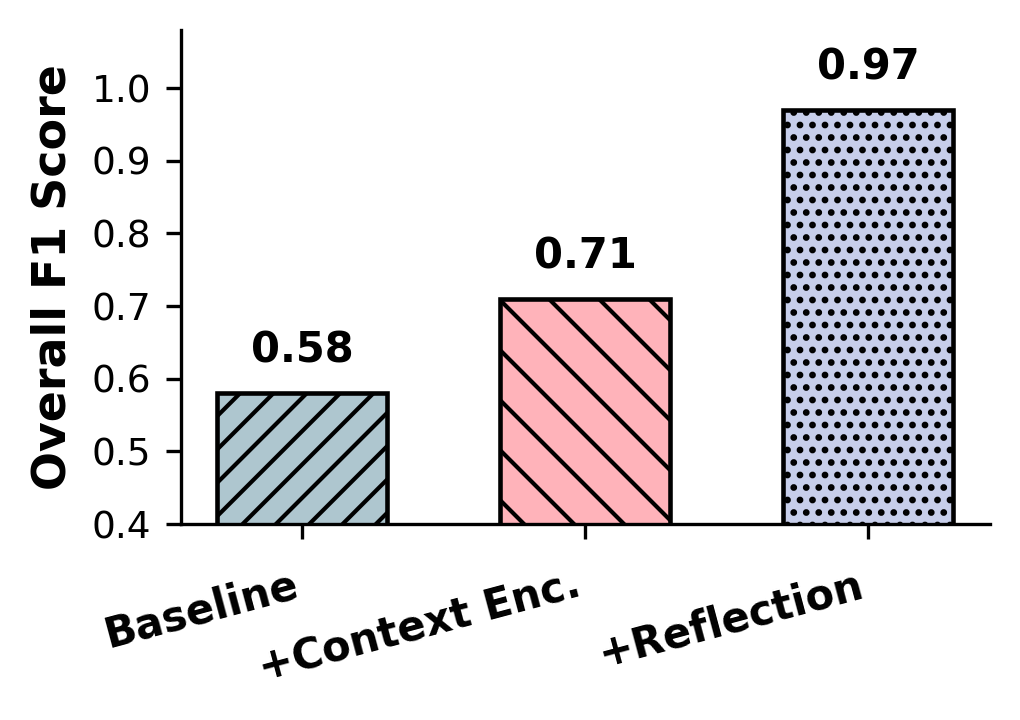

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ["Baseline", "+Context Enc.", "+Reflection"]
scores = [0.58, 0.71, 0.97]

x = np.arange(len(labels))

# Soft pastel colors
colors = ["#aec6cf", "#ffb3ba", "#c7ceea"]
hatches = ["///", "\\\\", "...."]

# Keep your preferred less-cramped size
fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

bars = ax.bar(
    x,
    scores,
    width=0.6,
    edgecolor="black",
    linewidth=1.1,
)

# Apply pastel colors + texture
for bar, color, hatch in zip(bars, colors, hatches):
    bar.set_facecolor(color)
    bar.set_hatch(hatch)

# Smaller fonts
ax.set_ylabel("Overall F1 Score", fontsize=11, fontweight="bold")
ax.set_ylim(0.4, 1.08)
ax.set_yticks(np.arange(0.4, 1.01, 0.1))
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", pad=6)   # increase the number to move them further down/right


ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, fontweight="bold", rotation=15, ha="right")

# Smaller bar-value labels
for xpos, val in zip(x, scores):
    ax.text(
        xpos,
        val + 0.03,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# No grid
ax.grid(False)

# Clean frame
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

# Save if needed:
plt.savefig("ablation_overall_3.pdf", dpi=300, bbox_inches='tight')

plt.show()


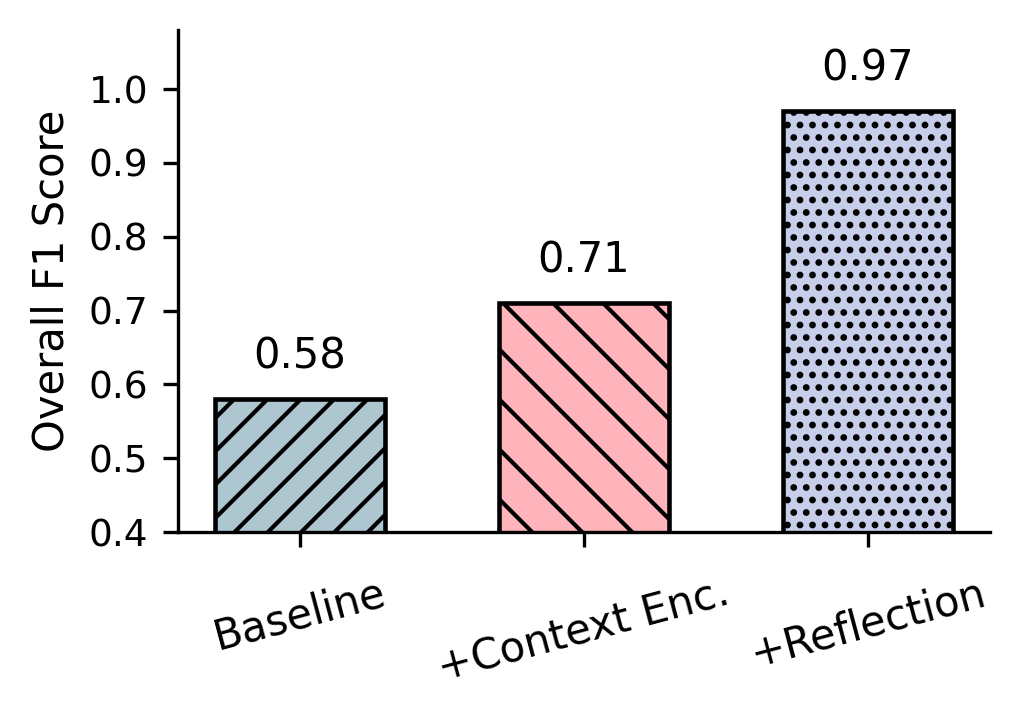

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ["Baseline", "+Context Enc.", "+Reflection"]
scores = [0.58, 0.71, 0.97]

x = np.arange(len(labels))

# Soft pastel colors
colors = ["#aec6cf", "#ffb3ba", "#c7ceea"]
hatches = ["///", "\\\\", "...."]

# Keep your preferred less-cramped size
fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

bars = ax.bar(
    x,
    scores,
    width=0.6,
    edgecolor="black",
    linewidth=1.1,
)

# Apply pastel colors + texture
for bar, color, hatch in zip(bars, colors, hatches):
    bar.set_facecolor(color)
    bar.set_hatch(hatch)

# Smaller fonts
ax.set_ylabel("Overall F1 Score", fontsize=10)
ax.set_ylim(0.4, 1.08)
ax.set_yticks(np.arange(0.4, 1.01, 0.1))
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", pad=6)   # increase the number to move them further down/right


ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, rotation=15, ha="center")

# Smaller bar-value labels
for xpos, val in zip(x, scores):
    ax.text(
        xpos,
        val + 0.03,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# No grid
ax.grid(False)

# Clean frame
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

# Save if needed:
plt.savefig("ablation_overall_4.pdf", dpi=300, bbox_inches='tight')

plt.show()
